# Notebook 2: A/B Test Analysis

## Campaign Experimentation Framework

This notebook analyzes **EXP-001: Email Subject Line Personalization**, a 2-variant A/B test measuring the impact of personalized subject lines on email engagement metrics.

We cover both **frequentist** and **Bayesian** analysis paradigms and compare their outputs directly. Both approaches are implemented in the framework — the choice depends on your organization's decision-making culture and risk tolerance.

**Metrics tested:**
- `open_rate` — primary metric (binary)
- `click_rate` — secondary metric (binary)
- `conversion_rate` — secondary metric (binary)
- `unsubscribe_rate` — guardrail metric (binary)

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")

from config import SIGNIFICANCE_LEVEL, CONFIDENCE_LEVEL, VISUALS_DIR, DATA_DIR
from src.ab_frequentist import FrequentistABTest
from src.ab_bayesian import BayesianABTest
from src.visualizations import ExperimentVisualizer
from src.recommendation_engine import RecommendationEngine

DATA_PATH = PROJECT_ROOT / DATA_DIR
VISUALS_PATH = PROJECT_ROOT / VISUALS_DIR
VISUALS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data directory   : {DATA_PATH}")
print(f"Visuals directory: {VISUALS_PATH}")
print(f"Significance level: {SIGNIFICANCE_LEVEL}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Data directory   : C:\Users\syeda\campaign-experimentation-framework\data
Visuals directory: C:\Users\syeda\campaign-experimentation-framework\visuals
Significance level: 0.05


## 2. Data Overview

Load `exp001_email_subject_line.csv` — the email subject line A/B test dataset.

In [2]:
df = pd.read_csv(DATA_PATH / "exp001_email_subject_line.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nVariant counts:")
print(df["variant"].value_counts().to_string())
print(f"\nDate range: {df['assignment_date'].min()} to {df['assignment_date'].max()}")

Shape: (50750, 13)

Columns: ['contact_id', 'variant', 'open_rate', 'click_rate', 'conversion_rate', 'unsubscribe_rate', 'spam_complaint_rate', 'day_of_week', 'assignment_date', 'industry', 'company_size', 'region', 'engagement_tier']

Variant counts:
variant
control      25410
treatment    25340

Date range: 2025-09-15 to 2025-10-14


In [3]:
display(df.head(8))

,contact_id,variant,open_rate,click_rate,conversion_rate,unsubscribe_rate,spam_complaint_rate,day_of_week,assignment_date,industry,company_size,region,engagement_tier
0,C00000000-a62f7e,control,1,0,0,0,0,6,2025-10-12,Technology,Mid-Market,LATAM,Low
1,C00000001-d9e107,control,0,0,0,0,0,1,2025-10-07,Technology,Mid-Market,North America,Medium
2,C00000002-f1b52a,control,0,0,0,0,0,6,2025-10-05,Finance,SMB,North America,Medium
3,C00000003-2517b6,control,0,0,0,0,0,6,2025-10-12,Retail,SMB,North America,Medium
4,C00000004-d9a826,control,0,0,0,0,0,0,2025-09-29,Technology,Mid-Market,EMEA,High
5,C00000005-f2293d,control,0,0,0,0,0,2,2025-10-01,Healthcare,Enterprise,North America,Low
6,C00000006-c8748c,control,0,0,0,0,0,0,2025-09-29,Finance,Mid-Market,North America,High
7,C00000007-96b461,control,0,0,0,0,0,1,2025-10-07,Retail,Mid-Market,North America,High


In [4]:
# Metric summaries per variant
metrics = ["open_rate", "click_rate", "conversion_rate", "unsubscribe_rate"]
metric_summary = df.groupby("variant")[metrics].agg(["mean", "sum", "count"])
print("Per-variant metric means:")
display(df.groupby("variant")[metrics].mean().round(4))

print("\nAbsolute counts (successes / n):")
for m in metrics:
    for v in ["control", "treatment"]:
        sub = df[df["variant"] == v]
        successes = int(sub[m].sum())
        n = len(sub)
        rate = successes / n
        print(f"  {v:<12} | {m:<25} | {successes:>5}/{n:>6} = {rate:.4f}")

Per-variant metric means:


,open_rate,click_rate,conversion_rate,unsubscribe_rate
variant,,,,
control,0.2186,0.0362,0.0074,0.0053
treatment,0.2562,0.0473,0.0110,0.0051



Absolute counts (successes / n):
  control      | open_rate                 |  5554/ 25410 = 0.2186
  treatment    | open_rate                 |  6491/ 25340 = 0.2562
  control      | click_rate                |   919/ 25410 = 0.0362
  treatment    | click_rate                |  1199/ 25340 = 0.0473
  control      | conversion_rate           |   189/ 25410 = 0.0074
  treatment    | conversion_rate           |   280/ 25340 = 0.0110
  control      | unsubscribe_rate          |   135/ 25410 = 0.0053
  treatment    | unsubscribe_rate          |   129/ 25340 = 0.0051


## 3. Frequentist Analysis

The `FrequentistABTest` class uses:
- **Two-proportion z-test** for binary metrics (with chi-squared cross-check)
- **Welch's t-test** with bootstrap CIs for continuous metrics

Results include: p-value, 95% CI for absolute lift, relative lift, Cohen's h effect size, and observed power.

In [5]:
freq_tester = FrequentistABTest(
    significance_level=SIGNIFICANCE_LEVEL,
    confidence_level=CONFIDENCE_LEVEL
)

control_df   = df[df["variant"] == "control"]
treatment_df = df[df["variant"] == "treatment"]

freq_results = {}
for metric in metrics:
    ctrl_successes  = int(control_df[metric].sum())
    ctrl_n          = len(control_df)
    treat_successes = int(treatment_df[metric].sum())
    treat_n         = len(treatment_df)

    result = freq_tester.analyze_proportion(
        control_successes=ctrl_successes,
        control_n=ctrl_n,
        treatment_successes=treat_successes,
        treatment_n=treat_n,
        metric_name=metric,
        experiment_id="EXP-001"
    )
    freq_results[metric] = result

    sig_marker = "***" if result.is_significant else "   "
    print(f"{metric:<26} {sig_marker} | "
          f"lift={result.absolute_lift:+.4f} ({result.relative_lift:+.2%}) | "
          f"p={result.p_value:.4f} | "
          f"CI=[{result.confidence_interval_absolute[0]:+.4f}, {result.confidence_interval_absolute[1]:+.4f}] | "
          f"power={result.power_achieved:.2f}")

open_rate                  *** | lift=+0.0376 (+17.19%) | p=0.0000 | CI=[+0.0302, +0.0450] | power=1.00
click_rate                 *** | lift=+0.0111 (+30.83%) | p=0.0000 | CI=[+0.0077, +0.0146] | power=1.00
conversion_rate            *** | lift=+0.0036 (+48.56%) | p=0.0000 | CI=[+0.0019, +0.0053] | power=0.99
unsubscribe_rate               | lift=-0.0002 (-4.18%) | p=0.7280 | CI=[-0.0015, +0.0010] | power=0.06


## 4. Visualizing Frequentist Results: Forest Plot

The forest plot (lift with 95% CI) is the standard visualization for A/B test results. Points to the right of zero indicate the treatment outperformed control. Green = statistically significant positive lift; grey = not significant.

Forest plot saved: C:\Users\syeda\campaign-experimentation-framework\visuals\EXP-001_lift_forest.png


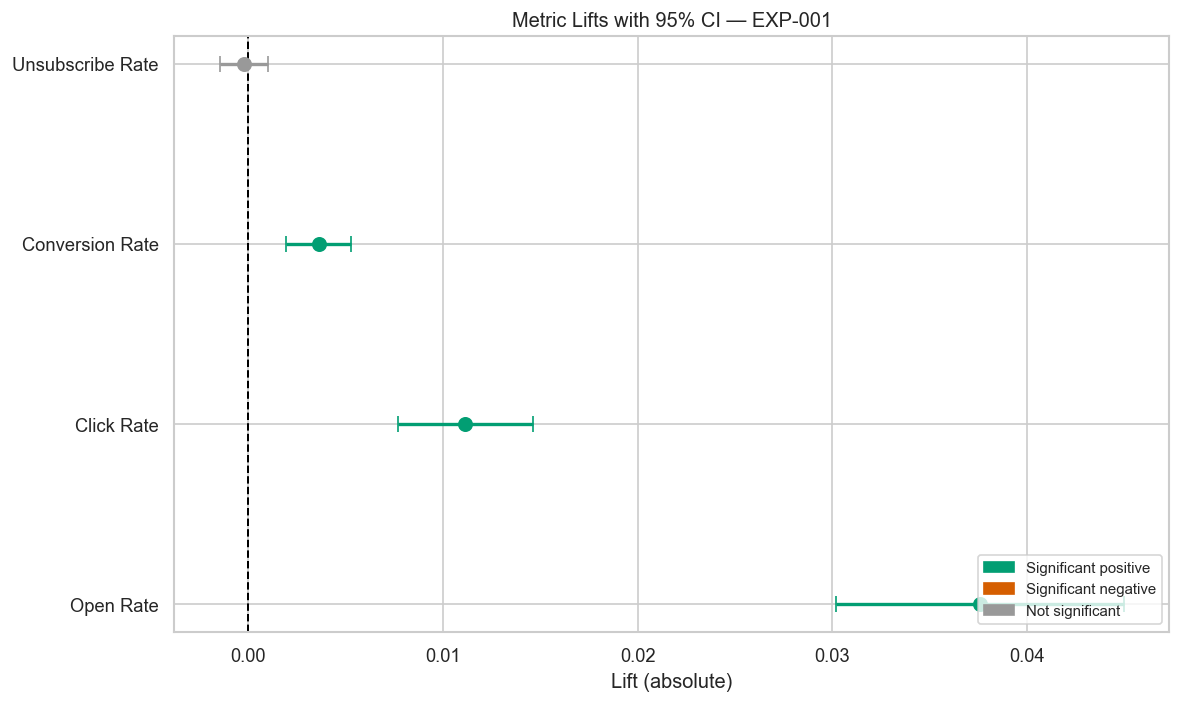

In [6]:
visualizer = ExperimentVisualizer(visuals_dir=VISUALS_PATH)

# Build the results list in the format expected by plot_lift_with_ci()
forest_data = []
for metric in metrics:
    r = freq_results[metric]
    forest_data.append({
        "metric_name": metric,
        "lift": r.absolute_lift,
        "ci_lower": r.confidence_interval_absolute[0],
        "ci_upper": r.confidence_interval_absolute[1],
        "is_significant": r.is_significant,
        "direction": "positive" if r.absolute_lift > 0 else "negative",
    })

forest_path = visualizer.plot_lift_with_ci(
    results=forest_data,
    metric_names=metrics,
    experiment_id="EXP-001"
)
print(f"Forest plot saved: {forest_path}")
display(Image(filename=forest_path))

## 5. Bayesian Analysis

The `BayesianABTest` class uses Beta-Binomial analytical inference (fast, no PyMC required). Key outputs:

- **P(treatment > control)** — the probability the treatment is genuinely better
- **Expected loss** — the cost of being wrong if we ship the treatment
- **95% HDI** — Highest Density Interval for the lift distribution
- **ROPE** — Region of Practical Equivalence: probability the lift is negligible
- **Decision** — SHIP_TREATMENT | SHIP_CONTROL | CONTINUE_TESTING | INCONCLUSIVE

The prior is `Beta(1, 1)` — uniform, meaning we have no prior information about open rates.

In [7]:
bayes_tester = BayesianABTest(mc_samples=100_000)

bayes_results = {}
for metric in metrics:
    ctrl_n          = len(control_df)
    treat_n         = len(treatment_df)
    ctrl_successes  = int(control_df[metric].sum())
    treat_successes = int(treatment_df[metric].sum())

    result = bayes_tester.analyze_proportion_analytical(
        control_successes=ctrl_successes,
        control_n=ctrl_n,
        treatment_successes=treat_successes,
        treatment_n=treat_n,
        metric_name=metric,
        experiment_id="EXP-001"
    )
    bayes_results[metric] = result

    print(f"{metric:<26} | "
          f"P(B>A)={result.probability_treatment_better:.4f} | "
          f"E[loss]={result.expected_loss_treatment:.5f} | "
          f"HDI=[{result.credible_interval_95[0]:+.4f}, {result.credible_interval_95[1]:+.4f}] | "
          f"Decision={result.decision}")

open_rate                  | P(B>A)=1.0000 | E[loss]=0.00000 | HDI=[+0.0302, +0.0450] | Decision=SHIP_TREATMENT
click_rate                 | P(B>A)=1.0000 | E[loss]=0.00000 | HDI=[+0.0076, +0.0146] | Decision=SHIP_TREATMENT
conversion_rate            | P(B>A)=1.0000 | E[loss]=0.00000 | HDI=[+0.0020, +0.0053] | Decision=SHIP_TREATMENT
unsubscribe_rate           | P(B>A)=0.3643 | E[loss]=0.00038 | HDI=[-0.0015, +0.0010] | Decision=INCONCLUSIVE


## 6. Visualizing Posteriors

We plot the posterior distributions for `open_rate`. The left panel shows the Beta posteriors for control and treatment. The right panel shows the lift distribution (treatment − control) with the 95% HDI shaded.

Posterior plot saved: C:\Users\syeda\campaign-experimentation-framework\visuals\EXP-001_posterior_open_rate.png


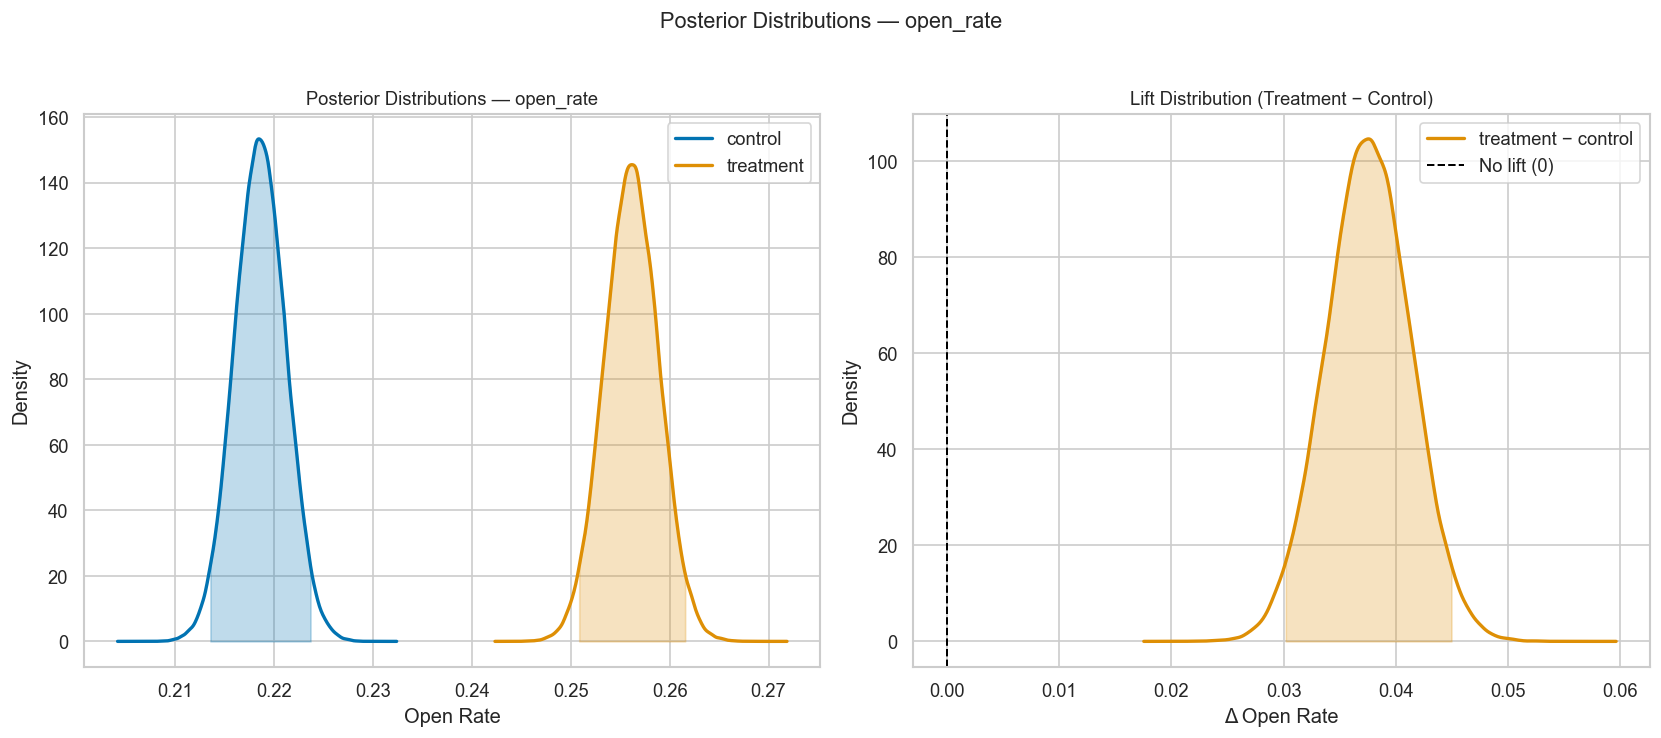

In [8]:
from scipy import stats as scipy_stats

# Reconstruct posterior samples for open_rate
metric = "open_rate"
ctrl_n   = len(control_df)
treat_n  = len(treatment_df)
ctrl_s   = int(control_df[metric].sum())
treat_s  = int(treatment_df[metric].sum())

# Beta posterior parameters (uniform prior: alpha=1, beta=1)
a_c, b_c = 1 + ctrl_s,  1 + (ctrl_n  - ctrl_s)
a_t, b_t = 1 + treat_s, 1 + (treat_n - treat_s)

rng = np.random.default_rng(42)
control_samples   = scipy_stats.beta.rvs(a_c, b_c, size=100_000, random_state=rng)
treatment_samples = scipy_stats.beta.rvs(a_t, b_t, size=100_000, random_state=rng)

posterior_path = visualizer.plot_posterior_distributions(
    posterior_samples={"control": control_samples, "treatment": treatment_samples},
    metric_name=metric,
    experiment_id="EXP-001"
)
print(f"Posterior plot saved: {posterior_path}")
display(Image(filename=posterior_path))

## 7. Side-by-Side Comparison: Frequentist vs Bayesian

Both frameworks answer the same underlying question — "did the treatment work?" — but express uncertainty differently:

- **Frequentist**: p-value (probability of seeing this data if H0 is true), confidence interval
- **Bayesian**: P(treatment > control), credible interval (HDI), expected loss

In [9]:
comparison_rows = []
for metric in metrics:
    f = freq_results[metric]
    b = bayes_results[metric]
    comparison_rows.append({
        "Metric": metric,
        "Control Rate": f"{f.control_metric:.4f}",
        "Treatment Rate": f"{f.treatment_metric:.4f}",
        "Abs Lift": f"{f.absolute_lift:+.4f}",
        # Frequentist
        "p-value": f"{f.p_value:.4f}",
        "Freq Sig?": "YES" if f.is_significant else "no",
        "95% CI": f"[{f.confidence_interval_absolute[0]:+.4f}, {f.confidence_interval_absolute[1]:+.4f}]",
        # Bayesian
        "P(B>A)": f"{b.probability_treatment_better:.4f}",
        "E[loss]": f"{b.expected_loss_treatment:.5f}",
        "95% HDI": f"[{b.credible_interval_95[0]:+.4f}, {b.credible_interval_95[1]:+.4f}]",
        "Decision": b.decision,
    })

comparison_df = pd.DataFrame(comparison_rows)
pd.set_option("display.max_colwidth", 35)
display(comparison_df)

,Metric,Control Rate,Treatment Rate,Abs Lift,p-value,Freq Sig?,95% CI,P(B>A),E[loss],95% HDI,Decision
0,open_rate,0.2186,0.2562,+0.0376,0.0000,YES,"[+0.0302, +0.0450]",1.0000,0.00000,"[+0.0302, +0.0450]",SHIP_TREATMENT
1,click_rate,0.0362,0.0473,+0.0111,0.0000,YES,"[+0.0077, +0.0146]",1.0000,0.00000,"[+0.0076, +0.0146]",SHIP_TREATMENT
2,conversion_rate,0.0074,0.0110,+0.0036,0.0000,YES,"[+0.0019, +0.0053]",1.0000,0.00000,"[+0.0020, +0.0053]",SHIP_TREATMENT
3,unsubscribe_rate,0.0053,0.0051,-0.0002,0.7280,no,"[-0.0015, +0.0010]",0.3643,0.00038,"[-0.0015, +0.0010]",INCONCLUSIVE


## 8. Full Experiment Report

The `RecommendationEngine` synthesizes all results into a plain-English recommendation with next steps. It accepts both `FrequentistResult` and `BayesianResult` objects and produces a formatted console report.

In [10]:
engine = RecommendationEngine()

# Use frequentist result for primary metric
primary_freq = freq_results["open_rate"]

# Secondary metrics as dicts
secondary = {
    "click_rate": {
        "absolute_lift": freq_results["click_rate"].absolute_lift,
        "p_value": freq_results["click_rate"].p_value,
        "is_significant": freq_results["click_rate"].is_significant,
    },
    "conversion_rate": {
        "absolute_lift": freq_results["conversion_rate"].absolute_lift,
        "p_value": freq_results["conversion_rate"].p_value,
        "is_significant": freq_results["conversion_rate"].is_significant,
    },
}

# Guardrail check for unsubscribe_rate
guardrail_results = []
unsub_f = freq_results["unsubscribe_rate"]
rel_change = unsub_f.relative_lift
guardrail_results.append({
    "metric_name": "unsubscribe_rate",
    "control_value": unsub_f.control_metric,
    "treatment_value": unsub_f.treatment_metric,
    "relative_change": rel_change,
    "p_value": unsub_f.p_value / 2,  # one-sided
    "is_degraded": (rel_change > 0.10 and unsub_f.p_value < 0.10),
    "message": f"Unsubscribe rate change: {rel_change:+.2%}",
})

report = engine.generate_report(
    experiment_id="EXP-001",
    experiment_name="Email Subject Line Personalization",
    primary_metric="open_rate",
    primary_result=primary_freq,
    secondary_results=secondary,
    guardrail_results=guardrail_results,
    test_duration_days=30,
)

print(engine.format_console_report(report))

EXPERIMENT REPORT: Email Subject Line Personalization (EXP-001)

VERDICT: SHIP TREATMENT  [confidence: high]

PRIMARY METRIC (open_rate):
  Control: 21.9%  |  Treatment: 25.6%
  Absolute Lift: +3.8%  |  Relative Lift: +17.2%
  Confidence: 100.0% probability treatment is better
  95% CI: [3.0%, 4.5%]

SECONDARY METRICS:
  click_rate: +1.1% lift (p=0.000) -- Significant
  conversion_rate: +0.4% lift (p=0.000) -- Significant

GUARDRAILS:
  unsubscribe_rate: -4.2% (p=0.364) -- No degradation

RECOMMENDATION:
  Ship treatment. Open Rate improved from 21.9% to 25.6% (+17.2% relative lift). 95% CI: [3.0%, 4.5%]. Secondary metrics also significant: click_rate, conversion_rate.

  Estimated impact: +1,907 additional opens per month

NEXT STEPS:
  1. Coordinate with engineering to roll out treatment to 100% of eligible audience.
  2. Monitor primary and guardrail metrics for 2 weeks post-full-launch.
  3. Document experiment learnings in the experiment catalog.
  4. Schedule a post-launch readou

In [11]:
print(f"\nVerdict: {report.overall_verdict}")
print(f"Confidence: {report.verdict_confidence}")
print(f"\nRecommendation:")
print(report.recommendation_text)
print(f"\nEstimated Annual Impact:")
print(report.estimated_annual_impact)
print(f"\nNext Steps:")
for i, step in enumerate(report.next_steps, 1):
    print(f"  {i}. {step}")


Verdict: SHIP_TREATMENT
Confidence: high

Recommendation:
Ship treatment. Open Rate improved from 21.9% to 25.6% (+17.2% relative lift). 95% CI: [3.0%, 4.5%]. Secondary metrics also significant: click_rate, conversion_rate.

Estimated Annual Impact:
+1,907 additional opens per month

Next Steps:
  1. Coordinate with engineering to roll out treatment to 100% of eligible audience.
  2. Monitor primary and guardrail metrics for 2 weeks post-full-launch.
  3. Document experiment learnings in the experiment catalog.
  4. Schedule a post-launch readout to share results with stakeholders.


## 9. Discussion: When to Use Frequentist vs Bayesian

### Frequentist (Two-Proportion Z-Test)
**Use when:**
- You have a pre-specified sample size and will analyze data exactly once at the end
- Your organization requires a clear p < 0.05 threshold for decision-making
- You need to control Type-I error rate precisely (e.g., regulatory environments)
- You want a simple, widely understood result to communicate to stakeholders

**Limitations:**
- Cannot be interpreted as "probability the treatment is better"
- Sensitive to peeking (repeated looks inflate false positive rate)
- p-value doesn't quantify the magnitude of evidence, only its existence

### Bayesian (Beta-Binomial)
**Use when:**
- You want to express results in business-friendly language ("97% confident treatment wins")
- You have prior knowledge about conversion rates from historical data
- You need to make a decision before reaching the pre-planned sample size
- You want to quantify the cost of being wrong (expected loss)

**Limitations:**
- Results depend on the prior (though with large n, data dominates)
- Less familiar to stakeholders trained on frequentist statistics
- More computationally expensive when using full MCMC

### In Practice
Both frameworks give nearly identical conclusions at large sample sizes. The key difference is **interpretation**. The Campaign Experimentation Framework runs both by default and flags discrepancies as signals to investigate further.